In [1]:
!pip install -q projectaria-tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 23.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 MB 10.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 57.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 13.2 MB/s eta 0:00:00


## Building Pipeline Using VRS of Object w/ Known Volume (Cuboid Box)

In [2]:
from projectaria_tools.core import data_provider
from projectaria_tools.core.sensor_data import TimeDomain, TimeQueryOptions

VRS_PATH = "/kaggle/input/datasets/vivankumarr/aria-box-scan/aria_box_calib.vrs"
provider = data_provider.create_vrs_data_provider(VRS_PATH)

for stream_id in provider.get_all_streams():
    print(f"ID {stream_id}: {provider.get_label_from_stream_id(stream_id)}  |  {provider.get_num_data(stream_id)} data points available")

ID 211-1: camera-et-left  |  142 data points available
ID 211-2: camera-et-right  |  142 data points available
ID 214-1: camera-rgb  |  284 data points available
ID 231-1: mic  |  1417 data points available
ID 246-1: temperature  |  678 data points available
ID 247-1: baro0  |  1415 data points available
ID 248-1: ppg  |  3641 data points available
ID 281-1: gps-app  |  26 data points available
ID 282-1: wps  |  26 data points available
ID 283-1: bluetooth  |  8 data points available
ID 371-2: handtracking  |  851 data points available
ID 371-3: vio  |  281 data points available
ID 371-4: vio_high_frequency  |  21789 data points available
ID 373-1: eyegaze  |  850 data points available
ID 500-1: als  |  283 data points available
ID 502-1: battery-status  |  0 data points available
ID 1201-1: slam-front-left  |  851 data points available
ID 1201-2: slam-front-right  |  851 data points available
ID 1201-3: slam-side-left  |  851 data points available
ID 1201-4: slam-side-right  |  851 da

[ProgressLogger][INFO]: 2026-08-27 01:08:34: Opening /kaggle/input/datasets/vivankumarr/aria-box-scan/aria_box_calib.vrs...
[TelemetryLogger][INFO]: RecordFileReader::doOpenFile, diskfile: success, 346714929
[VRSIndexRecord][WARNING]: 7 record(s) not sorted properly. Sorting index.
[RecordFileReader][DEBUG]: Reading TagsRecord for Button State Data Class #1
[TagsRecord][DEBUG]: Read 7 VRS tags and 0 user tags for Button State Data Class #1
[RecordFileReader][DEBUG]: Deleted 1 TagsRecords from the index.
[MultiRecordFileReader][DEBUG]: Opened file '/kaggle/input/datasets/vivankumarr/aria-box-scan/aria_box_calib.vrs' and assigned to reader #0
[VrsDataProvider][INFO]: streamId 211-1/camera-et-left activated
[VrsDataProvider][INFO]: streamId 211-2/camera-et-right activated
[VrsDataProvider][INFO]: streamId 214-1/camera-rgb activated
[VrsDataProvider][INFO]: streamId 231-1/mic activated
[VrsDataProvider][INFO]: streamId 246-1/temperature activated
[VrsDataProvider][INFO]: streamId 247-1/bar

### Keyframe Selection Along Camera Path

3.7116293748096036 m walked. Selected 40 keyframes.


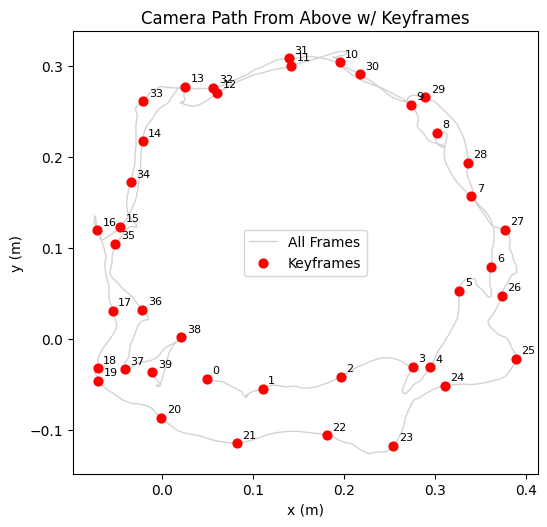

In [19]:
import numpy as np
import matplotlib.pyplot as plt

N_KEYFRAMES = 40
left_id = provider.get_stream_id_from_label("slam-front-left")
right_id = provider.get_stream_id_from_label("slam-front-right")
hf_vio_id = provider.get_stream_id_from_label("vio_high_frequency")

all_frame_timestamps_ns = np.array(provider.get_timestamps_ns(left_id, TimeDomain.DEVICE_TIME))
vio_timestamps_ns = np.array(provider.get_timestamps_ns(hf_vio_id, TimeDomain.DEVICE_TIME))

# Only keep frames that were present after VIO was initialized
vio_covered = all_frame_timestamps_ns >= vio_timestamps_ns[0]
frame_source_indices = np.nonzero(vio_covered)[0]
frame_timestamps_ns = all_frame_timestamps_ns[vio_covered]

# Get camera positions from VIO pose sampled closest to each frame's timestamp
camera_positions = np.array([provider.get_vio_high_freq_data_by_time_ns(
                                hf_vio_id, int(timestamp_ns), TimeDomain.DEVICE_TIME, 
                                TimeQueryOptions.CLOSEST
                             ).transform_odometry_device.translation().ravel()
                             for timestamp_ns in frame_timestamps_ns
                           ])

# Get displacement vectors for each change in position between consecutive frames
step_vectors = np.diff(camera_positions, axis=0)
step_lengths = np.linalg.norm(step_vectors, axis=1)

# Convert the values into distance walked so far
distance_traveled = np.concatenate([[0.0], np.cumsum(step_lengths)])
total_distance = distance_traveled[-1]

target_distances = np.linspace(0.0, total_distance, N_KEYFRAMES)
keyframe_indices = np.searchsorted(distance_traveled, target_distances)
keyframe_timestamps_ns = frame_timestamps_ns[keyframe_indices]
keyframe_positions = camera_positions[keyframe_indices]

# keyframe_indices stores the 0-indexed frame indices in the filtered frame list, but we need the indices from the original frame list
keyframe_frame_indices = frame_source_indices[keyframe_indices]

print(f"{total_distance} m walked. Selected {len(keyframe_indices)} keyframes.")

# Plot where each keyframe landed on the camera path in odometry frame
plt.figure(figsize=(6, 6))
plt.plot(camera_positions[:, 0], camera_positions[:, 1], color="lightgray", linewidth=1, label="All Frames")
plt.scatter(keyframe_positions[:, 0], keyframe_positions[:, 1], color="red", s=40, zorder=3, label="Keyframes")

for k, (x, y) in enumerate(keyframe_positions[:, :2]):
    plt.annotate(str(k), (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.gca().set_aspect("equal")
plt.xlabel("x (m)");
plt.ylabel("y (m)")
plt.title("Camera Path From Above w/ Keyframes")
plt.legend();
plt.show()
plt.close()

### Loading Stereo Image Pair for Each Keyframe

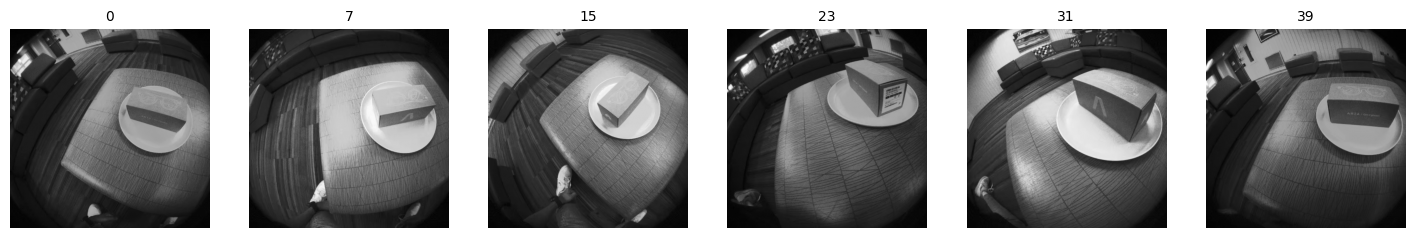

In [4]:
keyframe_left_images = []
keyframe_right_images = []

for frame_idx in keyframe_frame_indices:
    left_img, _ = provider.get_image_data_by_index(left_id, int(frame_idx))
    right_img, _ = provider.get_image_data_by_index(right_id, int(frame_idx))

    # All images are (512, 512) single-channel
    keyframe_left_images.append(left_img.to_numpy_array())
    keyframe_right_images.append(right_img.to_numpy_array())

# Stacked into (21, 512, 512) shape
keyframe_left_images = np.array(keyframe_left_images)
keyframe_right_images = np.array(keyframe_right_images)

# Make sure good frames were selected
preview_slots = np.linspace(0, len(keyframe_left_images) - 1, 6).astype(int)
fig, axes = plt.subplots(1, 6, figsize=(18, 3))

for axis, slot in zip(axes, preview_slots):
    axis.imshow(keyframe_left_images[slot], cmap="gray")
    axis.set_title(f"{slot}", fontsize=10)
    axis.axis("off")
plt.show()
plt.close()

### Stereo Rectification

In [5]:
import sys

!git clone -q https://github.com/facebookresearch/projectaria_gen2_depth_from_stereo.git /kaggle/working/depth_from_stereo
sys.path.insert(0, "/kaggle/working/depth_from_stereo")

fatal: destination path '/kaggle/working/depth_from_stereo' already exists and is not an empty directory.


Rectified Pinhole: fx=305.00084827176016, fy=305.00084827176016, cx=252.14995605042407, cy=257.68535123253
Rectified Image Shapes: (40, 512, 512) (40, 512, 512)


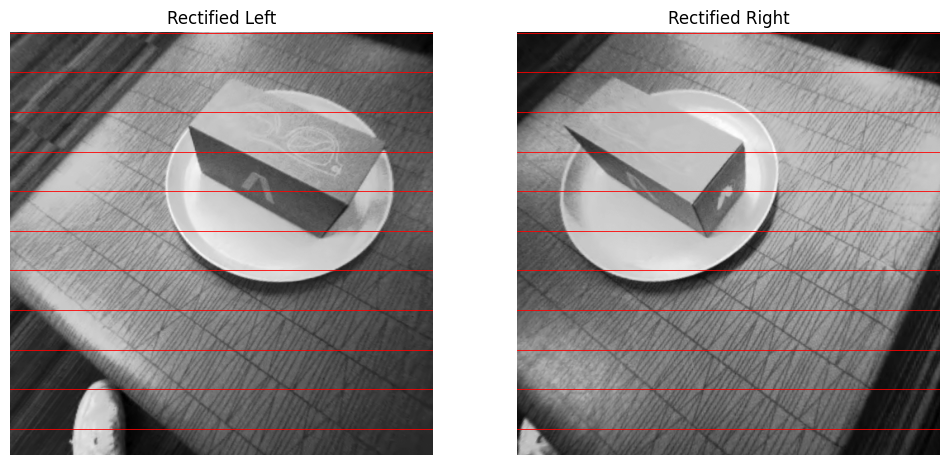

In [6]:
import stereo_utils
from projectaria_tools.core.image import InterpolationMethod

device_calib = provider.get_device_calibration()
left_calib = device_calib.get_camera_calib("slam-front-left")
right_calib = device_calib.get_camera_calib("slam-front-right")

T_leftCam_device = left_calib.get_transform_device_camera().inverse()
T_rightCam_device = right_calib.get_transform_device_camera().inverse()

# Create pinhole camera using Meta's helpers. Keep original principal point since it'll be the same
image_height, image_width = keyframe_left_images.shape[1:3]
rect_calib = stereo_utils.fisheye_to_linear_calib(left_calib, focal_scale=1.25, output_width=image_width,
                                                  output_height=image_height, use_original_pp=True)
fx, fy, cx, cy = rect_calib.get_projection_params()

# Get both rotations needed to turn the cameras into shared, rectified orientation
R_left_rect, R_right_rect = stereo_utils.create_scanline_rectified_cameras(T_leftCam_device, T_rightCam_device)
print(f"Rectified Pinhole: fx={fx}, fy={fy}, cx={cx}, cy={cy}")

rectified_left_images = []
rectified_right_images = []

for left_img, right_img in zip(keyframe_left_images, keyframe_right_images):
    rect_left, rect_right = stereo_utils.rectify_stereo_pair(left_img, right_img, left_calib, right_calib, rect_calib, rect_calib,
                                                             R_left_rect, R_right_rect, InterpolationMethod.BILINEAR)
    rectified_left_images.append(np.squeeze(rect_left))
    rectified_right_images.append(np.squeeze(rect_right))

rectified_left_images = np.array(rectified_left_images)
rectified_right_images = np.array(rectified_right_images)
print("Rectified Image Shapes:", rectified_left_images.shape, rectified_right_images.shape)

check_idx = 10
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for axis, image, name in zip(axes, [rectified_left_images[check_idx], rectified_right_images[check_idx]], ["Rectified Left", "Rectified Right"]):
    axis.imshow(image, cmap="gray")
    for row in range(0, image_height, 48):
        axis.axhline(row, color="red", linewidth=0.6)
    axis.set_title(name)
    axis.axis("off")

plt.show()
plt.close()

### FoundationStereo Disparity to Depth

In [7]:
import os

os.environ["XFORMERS_DISABLED"] = "1"
!cd /kaggle/working/depth_from_stereo && git submodule update --init
!pip install -q timm omegaconf einops trimesh open3d

import torch
print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.5/745.5 kB 4.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.2 MB/s eta 0:00:0000:01:00:01
GPU: Tesla T4


In [8]:
import sys
from omegaconf import OmegaConf

FOUNDATION_STEREO_DIR = "/kaggle/working/depth_from_stereo/FoundationStereo"
sys.path.insert(0, FOUNDATION_STEREO_DIR)

from core.foundation_stereo import FoundationStereo

CKPT_PATH = "/kaggle/input/datasets/vivankumarr/foundationstereo-checkpoint/model_best_bp2.pth"
stereo_cfg = OmegaConf.load(os.path.join(os.path.dirname(CKPT_PATH), "cfg.yaml"))
stereo_cfg["vit_size"] = "vitl"
stereo_cfg.valid_iters = 32

stereo_model = FoundationStereo(stereo_cfg)
checkpoint = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
stereo_model.load_state_dict(checkpoint["model"])

# Switch layers like norm and dropout to inference behavior
stereo_model = stereo_model.cuda().eval()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:45: UserWarning: xFormers is disabled (SwiGLU)
  warnings.warn("xFormers is disabled (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:29: UserWarning: xFormers is disabled (Attention)
  warnings.warn("xFormers is disabled (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:35: UserWarning: xFormers is disabled (Block)
  warnings.warn("xFormers is disabled (Block)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xForm

/kaggle/working/depth_from_stereo/FoundationStereo/core/foundation_stereo.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/kaggle/working/depth_from_stereo/FoundationStereo/core/submodule.py:390: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/kaggle/working/depth_from_stereo/FoundationStereo/core/geometry.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/kaggle/working/depth_from_stereo/FoundationStereo/core/foundation_stereo.py:245: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


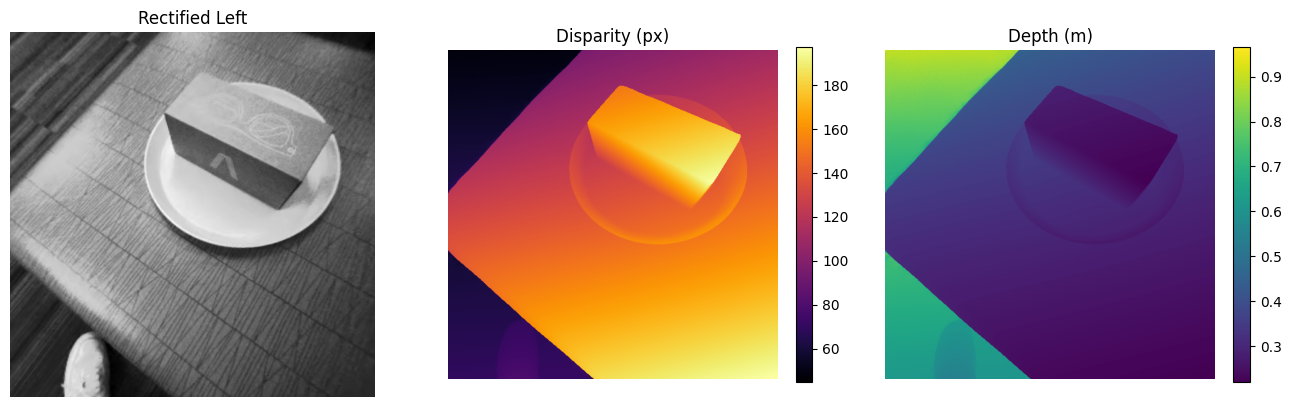

In [ ]:
    def compute_disparity(rect_left, rect_right):
        """ Use FoundationStereo to compute a dense disparity map for each pair of rectified images. """
        left_rgb = np.stack([rect_left] * 3, axis=-1)
        right_rgb = np.stack([rect_right] * 3, axis=-1)

        # Change arrays from HWC to BCHW
        left_tensor = torch.from_numpy(left_rgb).float().cuda().permute(2, 0, 1).unsqueeze(0)
        right_tensor = torch.from_numpy(right_rgb).float().cuda().permute(2, 0, 1).unsqueeze(0)

        with torch.amp.autocast("cuda"):
            with torch.no_grad():
                disparity = stereo_model.forward(left_tensor, right_tensor, iters=stereo_cfg.valid_iters, test_mode=True)

        return disparity.float().cpu().numpy().squeeze()

test_idx = 10
test_disparity = compute_disparity(rectified_left_images[test_idx], rectified_right_images[test_idx])

# Depth = (Baseline * Focal Length) / Disparity
baseline_m = stereo_utils.compute_stereo_baseline(T_leftCam_device, T_rightCam_device)
test_depth = stereo_utils.disparity_to_depth(test_disparity, baseline_m, fx)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(rectified_left_images[test_idx], cmap="gray")
axes[0].set_title("Rectified Left")

disparity_plot = axes[1].imshow(test_disparity, cmap="inferno")
axes[1].set_title("Disparity (px)")
plt.colorbar(disparity_plot, ax=axes[1], fraction=0.046)

depth_plot = axes[2].imshow(test_depth, cmap="viridis")
axes[2].set_title("Depth (m)")
plt.colorbar(depth_plot, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.axis("off")
plt.show()
plt.close()

### Using Poses to Convert 3D Coordinates Into World Frame + Backprojection

In [10]:
keyframe_depths = []

for keyframe_idx, (rect_left, rect_right) in enumerate(zip(rectified_left_images, rectified_right_images)):
    disparity = compute_disparity(rect_left, rect_right)
    depth = stereo_utils.disparity_to_depth(disparity, baseline_m, fx)
    keyframe_depths.append(depth)

# Stack into (40, 512, 512) like the keyframe array shape
keyframe_depths = np.array(keyframe_depths)

# Cache depth maps along with metadata
np.savez_compressed(
    "/kaggle/working/keyframe_depths.npz",
    depth=keyframe_depths,
    intrinsics=np.array([fx, fy, cx, cy]),
    baseline_m=baseline_m,
    timestamps_ns=keyframe_timestamps_ns
)
print("Keyframe Depths Array Shape:", keyframe_depths.shape)

Keyframe Depths Array Shape: (40, 512, 512)


In [11]:
keyframe_poses = []
for timestamp_ns in keyframe_timestamps_ns:
    vio_sample = provider.get_vio_high_freq_data_by_time_ns(hf_vio_id, int(timestamp_ns), 
                                                            TimeDomain.DEVICE_TIME, TimeQueryOptions.CLOSEST)
    T_world_device = vio_sample.transform_odometry_device
    # Use Meta's helper to chain poses and get from rectified left cam to world
    T_world_rectCam = stereo_utils.compute_T_world_rectCam(T_world_device, T_leftCam_device, R_left_rect)
    keyframe_poses.append(T_world_rectCam.to_matrix())

# One 4x4 pose matrix per keyframe
keyframe_poses = np.array(keyframe_poses)
print("Keyframe Poses Array Shape:", keyframe_poses.shape)

Keyframe Poses Array Shape: (40, 4, 4)


In [12]:
def backproject_depth_map(depth_map, fx, fy, cx, cy):
    """ Convert a depth map into an array of 3D coordinates in the rectified left CV camera's coordinate frame. """
    height, width = depth_map.shape
    u, v = np.meshgrid(np.arange(width), np.arange(height), indexing="xy")

    # Rearranged pinhole model formulas
    x = (u - cx) * depth_map / fx
    y = (v - cy) * depth_map / fy
    z = depth_map

    # Shape is (H, W, 3)
    return np.stack([x, y, z], axis=-1)
    
def fit_plane_ransac(points, inlier_threshold_m=0.002, num_iterations=300, seed=0):
    """
    Find the plane supported by the largest number of selected points. Also return a boolean
    mask array indicating which input points supported the final plane.
    """
    rng = np.random.default_rng(seed)
    best_inlier_mask, best_count = None, -1

    for _ in range(num_iterations):
        # Take 3 random points, fit a plane through them, keep the best plane
        p0, p1, p2 = points[rng.choice(len(points), 3, replace=False)]

        normal = np.cross(p1 - p0, p2 - p0)
        length = np.linalg.norm(normal)

        # If the points are collinear, they don't define a plane so skip
        if length < 1e-9:
            continue
        normal = normal / length
        offset = -normal @ p0

        # Compute signed perpendicular distance of all points to this plane and counter inliers
        inlier_mask = np.abs(points @ normal + offset) < inlier_threshold_m
        if inlier_mask.sum() > best_count:
            best_count, best_inlier_mask = inlier_mask.sum(), inlier_mask

    inlier_points = points[best_inlier_mask]
    centroid = inlier_points.mean(axis=0)
    centered = inlier_points - centroid

    # PCA to get direction of smallest point spread (i.e., fit plane's normal)
    scatter_matrix = centered.T @ centered
    eigenvalues, eigenvectors = np.linalg.eigh(scatter_matrix)
    normal = eigenvectors[:, 0]
    offset = -normal @ centroid

    if offset < 0:
        normal = -normal
        offset = -offset

    return normal, offset, best_inlier_mask

def depth_to_world_points(depth_map, pose_matrix):
    """ Backproject one depth map into 3D and place it in the shared world frame. """
    points_cam = backproject_depth_map(depth_map, fx, fy, cx, cy)

    # Apply the rigid transform to convert from rect left frame to world frame
    return points_cam @ pose_matrix[:3, :3].T + pose_matrix[:3, 3]

### SAM 2 Segmentation

In [13]:
!pip install -q git+https://github.com/facebookresearch/sam2.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 658.8 kB/s eta 0:00:00 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 2.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 6.5 MB/s eta 0:00:00


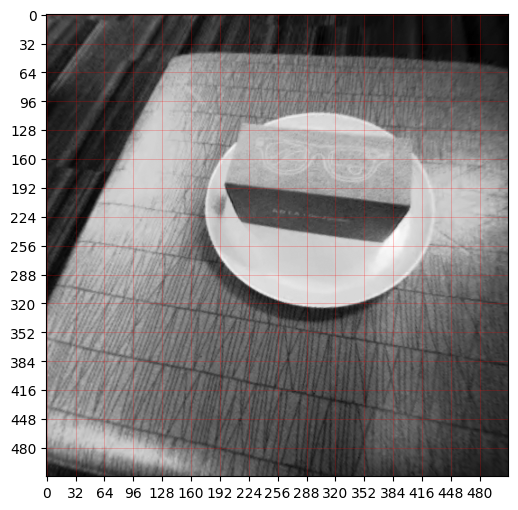

In [14]:
import os
import shutil
from PIL import Image

SAM_FRAMES_DIR = "/kaggle/working/sam_frames"
shutil.rmtree(SAM_FRAMES_DIR, ignore_errors=True)
os.makedirs(SAM_FRAMES_DIR, exist_ok=True)

for keyframe_idx, rect_left in enumerate(rectified_left_images):
    # Convert the monochrome images into 3-channel RGB and save as JPEGs for video mode
    rgb_frame = np.stack([rect_left] * 3, axis=-1)
    Image.fromarray(rgb_frame).save(f"{SAM_FRAMES_DIR}/{keyframe_idx:05d}.jpg", quality=95)

# The frame that the click prompt lands on (same mask will propagate across video)
plt.figure(figsize=(6, 6))
plt.imshow(rectified_left_images[0], cmap="gray")
plt.xticks(np.arange(0, 512, 32))
plt.yticks(np.arange(0, 512, 32))
plt.grid(color="red", alpha=0.3, linewidth=0.5)
plt.show()
plt.close()

sam2.1_hiera_large.pt:   0%|          | 0.00/898M [00:00<?, ?B/s]

Loaded checkpoint sucessfully
frame loading (JPEG): 100%|██████████| 40/40 [00:01<00:00, 34.27it/s]
/usr/local/lib/python3.12/dist-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/usr/local/lib/python3.12/dist-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 40/40 [00:55<00:00,  1.38s/it]


Food Masks Shape: (40, 512, 512) bool
Plate Masks Shape: (40, 512, 512) bool


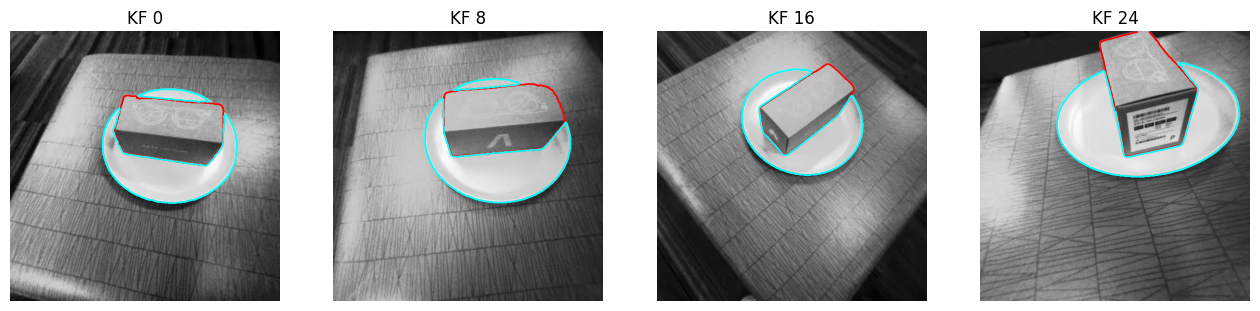

In [15]:
from sam2.sam2_video_predictor import SAM2VideoPredictor

FOOD_PROMPT_XY = (320, 160)
PLATE_PROMPT_XY = (288, 288)
FOOD_ID, PLATE_ID = 1, 2

predictor = SAM2VideoPredictor.from_pretrained("facebook/sam2.1-hiera-large").cuda()

# Initialize the frame index, allocate SAM 2 memory bank, etc.
inference_state = predictor.init_state(video_path=SAM_FRAMES_DIR, offload_video_to_cpu=True)
prompt_points = np.array([FOOD_PROMPT_XY, PLATE_PROMPT_XY], dtype=np.float32)

# Point prompt for food mask (box in example), negative click prompt on plate so they don't mix
predictor.add_new_points_or_box(inference_state=inference_state, frame_idx=0, obj_id=FOOD_ID,
                                points=prompt_points, labels=np.array([1, 0], dtype=np.int32))

# Point prompt for plate mask
predictor.add_new_points_or_box(inference_state=inference_state, frame_idx=0, obj_id=PLATE_ID,
                                points=prompt_points, labels=np.array([0, 1], dtype=np.int32))

food_masks = np.zeros((N_KEYFRAMES, image_height, image_width), dtype=bool)
plate_masks = np.zeros((N_KEYFRAMES, image_height, image_width), dtype=bool)

for frame_idx, obj_ids, mask_logits in predictor.propagate_in_video(inference_state):
    for slot, obj_id in enumerate(obj_ids):
        mask = (mask_logits[slot, 0] > 0.0).cpu().numpy()
        if obj_id == FOOD_ID:
            food_masks[frame_idx] = mask
        else:
            plate_masks[frame_idx] = mask

print("Food Masks Shape:", food_masks.shape, food_masks.dtype)
print("Plate Masks Shape:", plate_masks.shape, plate_masks.dtype)

show_indices = [0, 8, 16, 24]
fig, axes = plt.subplots(1, len(show_indices), figsize=(16, 4))

for axis, idx in zip(axes, show_indices):
    axis.imshow(rectified_left_images[idx], cmap="gray")

    axis.contour(food_masks[idx].astype(float),  levels=[0.5], colors="red",  linewidths=1.2)
    axis.contour(plate_masks[idx].astype(float), levels=[0.5], colors="cyan", linewidths=1.2)

    axis.set_title(f"KF {idx}")
    axis.axis("off")

plt.show()
plt.close()

In [54]:
from scipy.ndimage import binary_dilation

DEPTH_MIN_M, DEPTH_MAX_M = 0.05, 1.20  # Only consider masks valid in this distance range
FOOD_KEEPOUT_PX = 10

stride_grid = np.zeros((image_height, image_width), dtype=bool)
stride_grid[::4, ::4] = True  # Stride of 4 since all plate points not necessary
plate_points_world = []

for depth_map, food_mask, plate_mask, pose_matrix in zip(keyframe_depths, food_masks, plate_masks, keyframe_poses):
    points_world = depth_to_world_points(depth_map, pose_matrix)
    depth_ok = (depth_map > DEPTH_MIN_M) & (depth_map < DEPTH_MAX_M)

    # Dilate the mask by about FOOD_KEEPOUT_PX pixels so the food mask doesn't mess up the plane fit
    food_keepout = binary_dilation(food_mask, np.ones((3, 3), bool), iterations=FOOD_KEEPOUT_PX)
    plate_usable = plate_mask & ~food_keepout & stride_grid & depth_ok

    # Get (512 * 512, 3) list of world points for plate
    plate_points_world.append(points_world[plate_usable])
    
# (40 * (512 * 512), 3) point cloud (compiled from all keyframes, stacked on top of each other)
plate_points_world = np.vstack(plate_points_world)
plane_normal, plane_offset, plane_inliers = fit_plane_ransac(plate_points_world, inlier_threshold_m=0.003, num_iterations=300)

print("Plane Normal:", plane_normal)

Plane Normal: [-0.00914906 -0.01781792  0.99979939]


### TSDF Fusion

In [55]:
import open3d as o3d
from scipy.ndimage import binary_erosion

VOXEL_SIZE_M = 0.0025
TRUNCATION_M = 4 * VOXEL_SIZE_M
MASK_EROSION_PX = 2

tsdf_volume = o3d.pipelines.integration.ScalableTSDFVolume(voxel_length=VOXEL_SIZE_M, sdf_trunc=TRUNCATION_M,
                                                           color_type=o3d.pipelines.integration.TSDFVolumeColorType.NoColor)
o3d_intrinsics = o3d.camera.PinholeCameraIntrinsic(image_width, image_height, fx, fy, cx, cy)
dummy_color = o3d.geometry.Image(np.zeros((image_height, image_width, 3), dtype=np.uint8))

for depth_map, food_mask, pose_matrix in zip(keyframe_depths, food_masks, keyframe_poses):
    # Opposite of dilation: shrink the food mask so it doesn't get messed up by the plate depth values
    eroded_mask = binary_erosion(food_mask, np.ones((3, 3), bool), iterations=MASK_EROSION_PX)
    valid = eroded_mask & (depth_map > DEPTH_MIN_M) & (depth_map < DEPTH_MAX_M)

    # Create RGBD image for TSDF fusion
    masked_depth = np.where(valid, depth_map, 0.0).astype(np.float32)
    rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(dummy_color, o3d.geometry.Image(np.ascontiguousarray(masked_depth)), 
                                                                    depth_scale=1.0, depth_trunc=DEPTH_MAX_M, convert_rgb_to_intensity=False)

    # Pass world-to-camera (inverse of camera-to-world) to o3d 
    tsdf_volume.integrate(rgbd_image, o3d_intrinsics, np.linalg.inv(pose_matrix))

# Marching cubes (walk voxels, find surface crossings, lerp and create triangles)
fused_mesh = tsdf_volume.extract_triangle_mesh()
fused_mesh.remove_degenerate_triangles()
fused_mesh.remove_duplicated_vertices()

# Keep only the largest connected component (food cover mesh) and remove random blobs in space
triangle_clusters, cluster_triangle_counts, _ = fused_mesh.cluster_connected_triangles()
triangle_clusters = np.asarray(triangle_clusters)
cluster_triangle_counts = np.asarray(cluster_triangle_counts)

largest_cluster = int(np.argmax(cluster_triangle_counts))
print(f"There are {len(cluster_triangle_counts)} components, and the largest one holds {cluster_triangle_counts[largest_cluster]} triangles")

fused_mesh.remove_triangles_by_mask(triangle_clusters != largest_cluster)
fused_mesh.remove_unreferenced_vertices()

There are 196 components, and the largest one holds 23738 triangles


TriangleMesh with 12149 points and 23738 triangles.

In [56]:
import copy

def build_plane_frame(plane_normal, plane_offset):
    """ Build the transform matrix T_plane_world, where resting plane is z = 0 (+z is up). """
    helper_vec = np.array([1.0, 0.0, 0.0])
    x_axis = np.cross(helper_vec, plane_normal)
    x_axis = x_axis / np.linalg.norm(x_axis)
    y_axis = np.cross(plane_normal, x_axis)

    # n . (-offset * n) + offset = -offset * (n . n) + offset = 0 so use -offset * n as simple plane origin
    plane_origin = -plane_offset * plane_normal

    # Build the rigid transform
    T_world_plane = np.eye(4)
    T_world_plane[:3, 0] = x_axis
    T_world_plane[:3, 1] = y_axis
    T_world_plane[:3, 2] = plane_normal
    T_world_plane[:3, 3] = plane_origin

    return np.linalg.inv(T_world_plane)
    
T_plane_world = build_plane_frame(plane_normal, plane_offset)
mesh_in_plane = copy.deepcopy(fused_mesh)
mesh_in_plane.transform(T_plane_world)

plane_frame_vertices = np.asarray(mesh_in_plane.vertices)
print("Z range (mm):", 1000 * plane_frame_vertices[:, 2].min(), "to", 1000 * plane_frame_vertices[:, 2].max())

Z range (mm): 1.5654844336501217 to 84.12075474367958


In [ ]:
import trimesh

CONTACT_TOLERANCE_MM = 25.0
PINHOLE_MAX_VERTICES = 20
PINHOLE_MAX_SPAN_MM = 12.0

# Cut the triangles that cross z = 0 (table plane)
clipped = o3d.t.geometry.TriangleMesh.from_legacy(mesh_in_plane).clip_plane(point=[0.0, 0.0, 0.0],
                                                                            normal=[0.0, 0.0, 1.0]).to_legacy()

# Don't want to modify the vertex/face containers stored in Open3D internal buffer
vertices = np.asarray(clipped.vertices).copy()
faces = np.asarray(clipped.triangles).copy()

def find_boundary_loops(faces):
    """ 
    Find the ordered vertex rings around every hole (boundary).
    Boundary edges are those that are only used by one triangle.
    """
    # Every single edge in the mesh (w/ duplicates)
    edges = np.sort(np.vstack([faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [2, 0]]]), axis=1)
    unique_edges, edge_counts = np.unique(edges, axis=0, return_counts=True)
    boundary_edges = unique_edges[edge_counts == 1]
    
    neighbors = {}
    # Build adjacency list of boundary vertices
    for a, b in boundary_edges:
        neighbors.setdefault(a, []).append(b)
        neighbors.setdefault(b, []).append(a)

    unused = {tuple(edge) for edge in boundary_edges}
    loops = []
    while unused:
        # Get an arbitrary unwalked edge from the set
        start_a, start_b = unused.pop()
        loop = [start_a, start_b]
        while True:
            current, previous = loop[-1], loop[-2]
            next_vertex = None
            for candidate in neighbors.get(current, []):
                key = (min(current, candidate), max(current, candidate))
                if candidate != previous and key in unused:
                    next_vertex = candidate
                    # Mark the edge as walked
                    unused.discard(key)
                    break
            
            if next_vertex is None or next_vertex == loop[0]:
                break
                    
            loop.append(next_vertex)
        loops.append(loop)

    # Two vertices can't bound a hole
    return [loop for loop in loops if len(loop) >= 3]

boundary_loops = find_boundary_loops(faces)

# Contact rings are unobserved footprint, pinholes are noise from marching cubes, and there may be unobserved regions
contact_loops, pinhole_loops, unobserved_loops = [], [], []
for loop in boundary_loops:
    loop_mm = 1000 * vertices[loop]
    if np.median(loop_mm[:, 2]) <= CONTACT_TOLERANCE_MM:
        contact_loops.append(loop)

    elif len(loop) <= PINHOLE_MAX_VERTICES and np.ptp(loop_mm, axis=0).max() <= PINHOLE_MAX_SPAN_MM:
        pinhole_loops.append(loop)

    else:
        unobserved_loops.append(loop)

print(f"Boundary Loops: {len(contact_loops)} are contact, {len(pinhole_loops)} are pinhole, and {len(unobserved_loops)} are unobserved.")

if unobserved_loops:
    raise RuntimeError(f"{len(unobserved_loops)} unobserved regions in the scan; re-record.")

# Drop the contact rings down to the plate (can look slightly odd sometimes but these triangles barely enclose volume)
for loop in contact_loops:
    vertices[loop, 2] = 0.0

# Make the mesh watertight by filling all holes via fan method
for loop in contact_loops + pinhole_loops:
    center = vertices[loop].mean(axis=0)
    # Force z-coordinate to plate plane (z = 0) only if it's a contact loop
    if loop in contact_loops:
        center[2] = 0.0

    center_index = len(vertices)
    vertices = np.vstack([vertices, center])
    # For each position k around the ring, build one triangle from the center, the vertex at k, and the vertex at k+1
    faces = np.vstack([faces, [[center_index, loop[k], loop[(k + 1) % len(loop)]]
                                for k in range(len(loop))]])

capped_mesh = trimesh.Trimesh(vertices, faces, process=False)
if not capped_mesh.is_watertight:
    capped_mesh.merge_vertices()
assert capped_mesh.is_watertight, "Mesh still open after capping."

capped_mesh.fix_normals()
volume_ml = abs(capped_mesh.volume) * 1e6
print(f"Volume of Box: {volume_ml} mL")

Boundary Loops: 15 are contact, 0 are pinhole, and 0 are unobserved.
Volume of Box: 1200.0960283696186 mL


#### Ground Truth Volume of the Box = 18 cm x 8 cm x 8 cm = 1152 mL

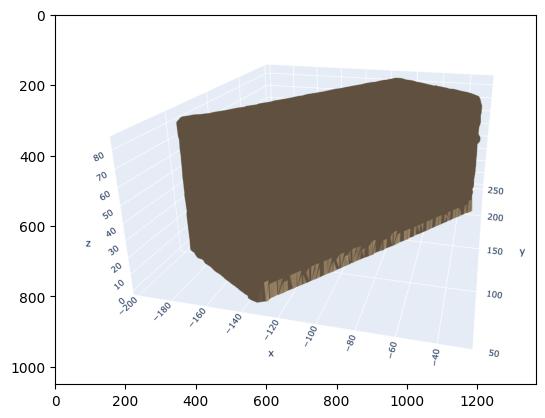

In [68]:
box_mesh_img = Image.open("/kaggle/working/plotly_box_mesh.png")
box_mesh_np = np.array(box_mesh_img)
box_mesh_np = box_mesh_np[300:]  # Crop
plt.imshow(box_mesh_np)